<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QTF007f.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

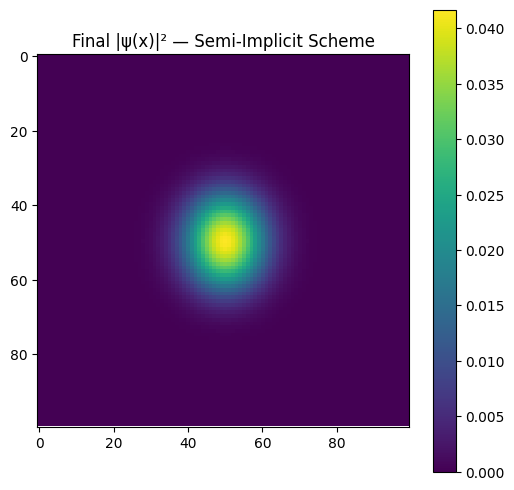

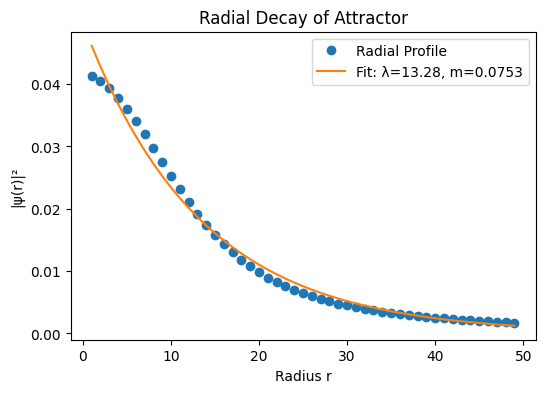

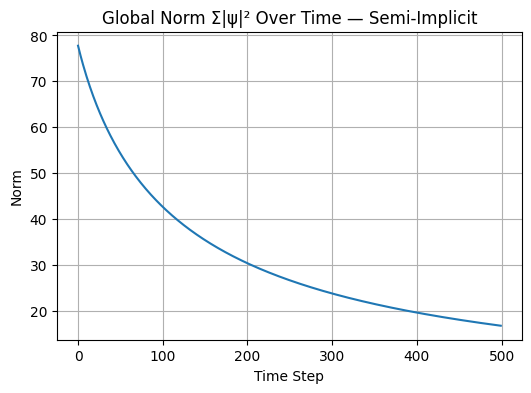

In [ ]:
# QFT007f: Semi-Implicit Scheme — γ = 0.08, ε = 0.10, T = 500
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Parameters
N = 100
T = 500
gamma = 0.08
epsilon = 0.10
A = 1.0
sigma = 5.0

# Seed initialization
x0, y0 = N//2, N//2
X, Y = np.meshgrid(np.arange(N), np.arange(N))
psi = A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)) + 1j * np.zeros((N, N))

# FFT Laplacian kernel
kx = np.fft.fftfreq(N).reshape((N, 1))
ky = np.fft.fftfreq(N).reshape((1, N))
laplacian_kernel = -4 * np.pi**2 * (kx**2 + ky**2)
implicit_denominator = 1 - gamma * laplacian_kernel

# Track global norm
norms = []

# Evolution loop
for t in range(T):
    # Explicit memory compensation
    delta_A2 = (
        np.roll(np.abs(psi)**2, 1, axis=0) + np.roll(np.abs(psi)**2, -1, axis=0)
        - 2 * np.abs(psi)**2
    )
    compensation = epsilon * delta_A2

    # Semi-implicit update: solve (I - γ∇²)ψ_new = ψ + ε δA²
    rhs = psi + compensation
    rhs_fft = np.fft.fft2(rhs)
    psi_new_fft = rhs_fft / implicit_denominator
    psi = np.fft.ifft2(psi_new_fft)

    norms.append(np.sum(np.abs(psi)**2))

# Final magnitude
magnitude = np.abs(psi)**2

# Radial profile extraction
radii = []
values = []
for r in range(1, N//2):
    shell = magnitude[x0-r:x0+r+1, y0-r:y0+r+1]
    shell_mean = np.mean(shell)
    radii.append(r)
    values.append(shell_mean)

# Fit exponential decay: |ψ(r)|² ~ exp(-r / λ_c)
def decay_func(r, a, lambda_c):
    return a * np.exp(-r / lambda_c)

try:
    params, _ = curve_fit(decay_func, radii, values, p0=(1.0, 10.0))
    lambda_c = params[1]
    mass = 1 / lambda_c
except:
    lambda_c = np.nan
    mass = np.nan

# Plot final field
plt.figure(figsize=(6, 6))
plt.imshow(magnitude, cmap='viridis')
plt.title('Final |ψ(x)|² — Semi-Implicit Scheme')
plt.colorbar()
plt.show()

# Plot radial decay and fit
plt.figure(figsize=(6, 4))
plt.plot(radii, values, 'o', label='Radial Profile')
if not np.isnan(mass):
    plt.plot(radii, decay_func(np.array(radii), *params), '-', label=f'Fit: λ={lambda_c:.2f}, m={mass:.4f}')
plt.title('Radial Decay of Attractor')
plt.xlabel('Radius r')
plt.ylabel('|ψ(r)|²')
plt.legend()
plt.show()

# Plot global norm over time
plt.figure(figsize=(6, 4))
plt.plot(norms)
plt.title('Global Norm Σ|ψ|² Over Time — Semi-Implicit')
plt.xlabel('Time Step')
plt.ylabel('Norm')
plt.grid(True)
plt.show()
